In [27]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from mcs_prime import mcs_prime_config_util as cu

In [42]:
datadir = cu.PATHS['datadir']
simdir = datadir / 'UM_sims'

EXPTS = {
    # 'ctrl': 'u-di727',    
    'vanillaMCSP': 'u-di728',    
    'stochMCSP': 'u-dg135',
}

In [43]:
expt_cf = {}
for expt, suite in EXPTS.items():
    cf_path = simdir / f'{suite}/processed/{expt}/engla_pa.mcsp_calling_freq.nc'
    expt_cf[expt] = xr.load_dataarray(cf_path)

In [53]:
cfmean_vanillaMCSP = expt_cf['vanillaMCSP'].isel(ens_mem=slice(1, 10)).mean(['ens_mem', 'time'])
cfmean_stochMCSP = expt_cf['stochMCSP'].isel(ens_mem=slice(1, 10)).mean(['ens_mem', 'time'])
cfmeans = {
    'vanillaMCSP': cfmean_vanillaMCSP,
    'stochMCSP': cfmean_stochMCSP,
}

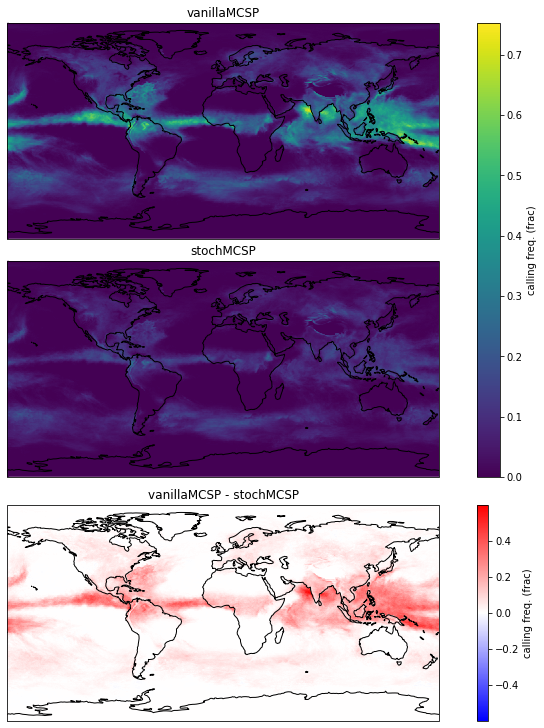

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
cfmax = max(
    cfmean_vanillaMCSP.values.max(), 
    cfmean_stochMCSP.values.max()
)
for ax, expt in zip(axes, expt_cf):
    cfmean = cfmeans[expt]
    ax.set_title(expt)
    ax.coastlines()
    im = ax.pcolormesh(cf.longitude, cf.latitude, cfmean, vmin=0, vmax=cfmax)
plt.colorbar(im, ax=axes[:2], label='calling freq. (frac)')

ax = axes[2]
ax.set_title('vanillaMCSP - stochMCSP')
ax.coastlines()
cf_diff = cfmean_vanillaMCSP - cfmean_stochMCSP
absmax = np.abs(cf_diff.values).max()
im = ax.pcolormesh(cf.longitude, cf.latitude, cf_diff, vmin=-absmax, vmax=absmax, cmap='bwr')
plt.colorbar(im, ax=ax, label='calling freq. (frac)')

In [56]:
# Makes it look like there are 8 timesteps an hour, or dt=7.5 mins.
vals, counts = np.unique(expt_cf['vanillaMCSP'].values, return_counts=True)
vals, counts

(array([0.   , 0.125, 0.25 , 0.375, 0.5  , 0.625, 0.75 , 0.875, 1.   ],
       dtype=float32),
 array([295924864,   6739793,   7323789,   2732223,   2484911,   2346961,
          4580384,   2608868,  11181407]))

In [33]:
# However, 
# mamue@xcslc0 /projects/mcsprime/mamue/cylc-run/u-dg135/work/20200701T0000Z/engl_um_fcst_em0_cr0 $ grep steps *
# ATMOSCNTL:steps_per_periodim=240,
# And this is backed up by looking in pe_output, which shows dt=6 mins.
# Why the discrepancy?

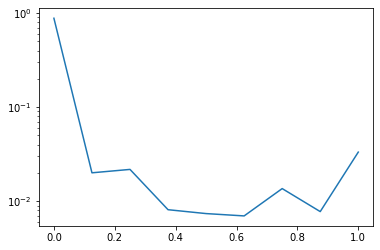

In [58]:
fig, ax = plt.subplots()
ax.plot(vals, counts / counts.sum())
ax.set_yscale('log')